# 05. ネガティブキャリー・レベル損失回避型 米国債戦略

このノートブックでは、これまでの `Miyazaki` 型・月次残差平均回帰型の相対価値シグナルに、**キャッシュ退避ゲート**を重ねる。

目的は明確に、以下を避けること。

- 短期金利対比で魅力のないネガティブキャリーを持つこと
- 2022年のような金利上昇局面で、レベル要因による大きなマイナスリターンを受けること
- 防御局面で無理にBM並みのデュレーションを持つこと

今回から、デュレーション一致制約は廃止し、3か月金利キャッシュを投資対象に加える。危険局面では100%キャッシュまで退避できる。

## 戦略の順番

おすすめ順に、以下を検証する。

1. `OUR_CASH_NOMINAL`: 前回提案の月次残差平均回帰 + キャッシュ + 名目金利ゲート
2. `MZ_CASH_NOMINAL`: Miyazaki型誤差項補正 + キャッシュ + 名目金利ゲート
3. `Miyazaki_Monthly_CASH_NOMINAL`: Miyazaki型を1か月ホライズンで再計算 + キャッシュ + 名目金利ゲート
4. `OUR_BEI_DEFENSE`: `OUR_CASH_NOMINAL` にBEI/実質金利ゲートを追加
5. `MZ_BEI_DEFENSE`: `MZ_CASH_NOMINAL` にBEI/実質金利ゲートを追加
6. `Miyazaki_Monthly_BEI_DEFENSE`: `Miyazaki_Monthly_CASH_NOMINAL` にBEI/実質金利ゲートを追加
7. `OUR_EARLY_CASH`: 2年金利モメンタムとBEI水準を加えた早期警戒・強制キャッシュ版
8. `MZ_EARLY_CASH`: Miyazaki型シグナルに同じ早期警戒・強制キャッシュを載せた版
9. `Miyazaki_Monthly_EARLY_CASH`: 月次Miyazaki型シグナルに同じ早期警戒・強制キャッシュを載せた版

特に2022年のような局面では、`EARLY_CASH` 系が100%キャッシュへ寄ることを狙う。

## セットアップ

利回りデータは既存の長期FREDデータを使う。短期金利・BEI・実質金利は `data/us_macro_rates_2004_2026.xlsx` から読み込む。

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import linprog
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401

YIELD_PATH = Path("../data/us_treasury_yields_2004_2026.xlsx")
MACRO_PATH = Path("../data/us_macro_rates_2004_2026.xlsx")
RESULT_PATH = Path("../data/backtest_defensive_cash_gated.xlsx")

CURVE_NODES = np.array([0.5, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)
MATURITIES = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30], dtype=float)
SECTOR_NAMES = ["1Y", "2Y", "3Y", "4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y", "15Y", "20Y", "30Y"]
N_SECTORS = len(MATURITIES)

LOOKBACK_MONTHS = 24
BACKTEST_START = pd.Timestamp("2006-04-30")
BACKTEST_LAST_SIGNAL = pd.Timestamp("2026-02-28")

MIYAZAKI_SIGNAL_HORIZON = 0.5
MIYAZAKI_GAMMA = 0.5
MONTHLY_GAMMA = 1 - 0.5 ** (1 / 6)

MAX_WEIGHT = 0.35
CASH_DURATION = 0.25
TRANSACTION_COST_BPS = 2.0

print(f"Miyazaki gamma: {MIYAZAKI_GAMMA:.3f}")
print(f"Monthly gamma: {MONTHLY_GAMMA:.4f}")

Miyazaki gamma: 0.500
Monthly gamma: 0.1091


## データ読み込み

`DGS3MO` をキャッシュ利回りとして使う。BEIは `T10YIE`、実質金利は `DFII10` を使う。`REAL10_PROXY = DGS10 - T10YIE` も参考として保存しているが、判定には公式TIPS実質金利 `DFII10` を使う。

In [2]:
yields = pd.read_excel(YIELD_PATH, sheet_name="yields", index_col=0, parse_dates=True)[SECTOR_NAMES]
curve_nodes = pd.read_excel(YIELD_PATH, sheet_name="source_nodes", index_col=0, parse_dates=True)
macro = pd.read_excel(MACRO_PATH, sheet_name="monthly", index_col=0, parse_dates=True)

print(f"利回り: {yields.index[0].date()}〜{yields.index[-1].date()}, {yields.shape}")
print(f"マクロ: {macro.index[0].date()}〜{macro.index[-1].date()}, {macro.shape}")
print(f"欠損セル数: yields={int(yields.isna().sum().sum())}, macro={int(macro.isna().sum().sum())}")
display(macro[["DGS3MO", "DGS2", "DGS10", "T10YIE", "DFII10", "SLOPE_10Y_3M"]].tail())

利回り: 2004-04-30〜2026-03-31, (264, 13)
マクロ: 2004-04-30〜2026-03-31, (264, 8)
欠損セル数: yields=0, macro=0


,DGS3MO,DGS2,DGS10,T10YIE,DFII10,SLOPE_10Y_3M
2025-11-30,3.88,3.47,4.02,2.23,1.79,0.14
2025-12-31,3.67,3.47,4.18,2.25,1.93,0.51
2026-01-31,3.67,3.52,4.26,2.36,1.90,0.59
2026-02-28,3.67,3.38,3.97,2.25,1.72,0.30
2026-03-31,3.70,3.79,4.30,2.30,2.00,0.60


## 債券価格・実現リターン

実現リターンは、時点 $t$ のパー債を1か月保有して、翌月末のカーブで評価する。キャッシュは時点 $t$ の3か月金利を1か月分に換算したリターンとする。

In [3]:
def year_fraction(start, end):
    return (end - start).days / 365.25


def cashflow_times(original_maturity, elapsed=0.0, freq=2):
    payment_times = np.arange(1 / freq, original_maturity + 1e-9, 1 / freq) - elapsed
    return payment_times[payment_times > 1e-10]


def price_bond_elapsed(y_coupon, y_discount, original_maturity, elapsed=0.0, freq=2):
    times = cashflow_times(original_maturity, elapsed=elapsed, freq=freq)
    if len(times) == 0:
        return 100.0
    coupon = y_coupon * 100 / freq
    cashflows = np.full(len(times), coupon)
    cashflows[-1] += 100
    return float(np.sum(cashflows / (1 + y_discount / freq) ** (freq * times)))


def dP_dy(y_coupon, y_discount, maturity, freq=2, dy=1e-5):
    p_up = price_bond_elapsed(y_coupon, y_discount + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y_coupon, y_discount - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - p_down) / (2 * dy)


def d2P_dy2(y_coupon, y_discount, maturity, freq=2, dy=1e-4):
    p_up = price_bond_elapsed(y_coupon, y_discount + dy, maturity, elapsed=0.0, freq=freq)
    p0 = price_bond_elapsed(y_coupon, y_discount, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y_coupon, y_discount - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - 2 * p0 + p_down) / dy**2


def modified_duration(y, maturity, freq=2, dy=1e-4):
    p0 = price_bond_elapsed(y, y, maturity, elapsed=0.0, freq=freq)
    p_up = price_bond_elapsed(y, y + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y, y - dy, maturity, elapsed=0.0, freq=freq)
    return -(p_up - p_down) / (2 * dy) / p0


def realized_sector_returns(row_sector_pct, next_node_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    next_curve = CubicSpline(CURVE_NODES, next_node_pct.astype(float) / 100, extrapolate=True)
    returns = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        y_next = float(next_curve(maturity - horizon))
        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_next, maturity, elapsed=horizon)
        returns.append(p1 / p0 - 1)
    return np.array(returns)


def cash_return(dt, horizon):
    return macro.loc[dt, "DGS3MO"] / 100 * horizon


print(f"10Y par price @ 3%: {price_bond_elapsed(0.03, 0.03, 10):.6f}")

10Y par price @ 3%: 100.000000


## ローリング因子モデルと相対価値シグナル

`OUR` は1か月ホライズンの残差平均回帰シグナル、`MZ` はMiyazaki型の半年CA&RDシグナルを月次比較できるように6で割ったもの。

今回追加する `Miyazaki_Monthly` は、宮崎論文のCA&RD+誤差項補正の構造を保ちながら、シグナル計算そのものを1か月ホライズンに直す。ロールダウン先は $T_i-\Delta_t$、キャリーは $\Delta_t$ 年分、誤差項修正率は

$$
\gamma_{\Delta_t}
=
1-(1-0.5)^{\Delta_t/0.5}
$$

とする。

In [4]:
def fit_factor_model(history_pct):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(history_pct.values.astype(float))
    fa = FactorAnalysis(n_components=3, random_state=42, max_iter=2000)
    fa.fit(scaled)
    return scaler, fa.components_.T


def estimate_model_yield(y_pct, scaler, loadings):
    y_scaled = scaler.transform(y_pct.reshape(1, -1)).ravel()
    factor_values = np.linalg.lstsq(loadings, y_scaled, rcond=None)[0]
    model_scaled = loadings @ factor_values
    model_pct = model_scaled * scaler.scale_ + scaler.mean_
    residual_pct = y_pct - model_pct
    return model_pct, residual_pct


def our_monthly_reversion_signal(row_sector_pct, model_pct, residual_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)
    signals = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        y_horizon = y_i + (
            float(model_curve(maturity - horizon))
            - model_pct[k] / 100
            - MONTHLY_GAMMA * residual_pct[k] / 100
        )
        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_horizon, maturity, elapsed=horizon)
        signals.append(p1 / p0 - 1)
    return np.array(signals)


def miyazaki_residual_gamma(horizon):
    return 1 - (1 - MIYAZAKI_GAMMA) ** (horizon / MIYAZAKI_SIGNAL_HORIZON)


def miyazaki_card_taylor(y_i, delta_y, maturity, horizon):
    p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
    rolled_maturity = max(maturity - horizon, 0.5)
    carry = y_i * 100 * horizon
    duration_term = dP_dy(y_i, y_i, rolled_maturity) * delta_y
    convexity_term = 0.5 * d2P_dy2(y_i, y_i, rolled_maturity) * delta_y**2
    return (carry + duration_term + convexity_term) / p0


def miyazaki_alpha_signal_monthly_scaled(row_sector_pct, model_pct, residual_pct):
    y_current = row_sector_pct.astype(float) / 100
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)
    signals = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        rolled_maturity = max(maturity - MIYAZAKI_SIGNAL_HORIZON, 0.5)
        model_i = model_pct[k] / 100
        delta_alpha = float(model_curve(rolled_maturity)) - (model_i + MIYAZAKI_GAMMA * residual_pct[k] / 100)
        half_year_signal = miyazaki_card_taylor(y_i, delta_alpha, maturity, MIYAZAKI_SIGNAL_HORIZON)
        signals.append(half_year_signal / 6)
    return np.array(signals)


def miyazaki_alpha_signal_monthly(row_sector_pct, model_pct, residual_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)
    gamma_h = miyazaki_residual_gamma(horizon)
    signals = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        rolled_maturity = max(maturity - horizon, 0.5)
        model_i = model_pct[k] / 100
        delta_alpha = float(model_curve(rolled_maturity)) - (model_i + gamma_h * residual_pct[k] / 100)
        signals.append(miyazaki_card_taylor(y_i, delta_alpha, maturity, horizon))
    return np.array(signals)

## 防御ゲート

3段階の防御状態を作る。

- `risk_on`: duration cap 8年、cash下限0%
- `caution`: duration capを落とし、cash下限を増やす
- `crisis`: cash下限100%、duration cap 0.25年

`early=True` の場合は、2021年末のような「まだ10年金利は大きく動いていないが、2年金利とBEIが警告している」局面を拾う。

In [5]:
def trailing_change(dt, column, months):
    hist = macro.loc[:dt, column]
    if len(hist) < months + 1:
        return 0.0
    return macro.loc[dt, column] - hist.iloc[-months - 1]


def risk_flags(dt, mode="nominal"):
    row = macro.loc[dt]
    flags = {
        "d10_3m_up": trailing_change(dt, "DGS10", 3) > 0.25,
        "d10_6m_up": trailing_change(dt, "DGS10", 6) > 0.50,
        "d3m_3m_up": trailing_change(dt, "DGS3MO", 3) > 0.25,
        "curve_inverted": row["SLOPE_10Y_3M"] < 0,
    }

    if mode in {"bei", "early"}:
        flags.update({
            "real_3m_up": trailing_change(dt, "DFII10", 3) > 0.25,
            "bei_3m_up": trailing_change(dt, "T10YIE", 3) > 0.15,
        })

    if mode == "early":
        flags.update({
            "d2_3m_up": trailing_change(dt, "DGS2", 3) > 0.25,
            "d2_6m_up": trailing_change(dt, "DGS2", 6) > 0.45,
            "bei_high": row["T10YIE"] > 2.45,
        })

    return flags


def defense_state(dt, mode="nominal"):
    score = int(sum(risk_flags(dt, mode).values()))

    if mode == "early":
        if score >= 4:
            return {"state": "crisis", "score": score, "duration_cap": CASH_DURATION, "min_cash": 1.0, "penalty_mult": 2.0}
        if score >= 2:
            return {"state": "caution", "score": score, "duration_cap": 1.5, "min_cash": 0.65, "penalty_mult": 1.25}
        return {"state": "risk_on", "score": score, "duration_cap": 8.0, "min_cash": 0.0, "penalty_mult": 0.25}

    if score >= 4:
        return {"state": "crisis", "score": score, "duration_cap": 0.75, "min_cash": 0.80, "penalty_mult": 1.25}
    if score >= 2:
        return {"state": "caution", "score": score, "duration_cap": 2.5, "min_cash": 0.40, "penalty_mult": 0.75}
    return {"state": "risk_on", "score": score, "duration_cap": 8.0, "min_cash": 0.0, "penalty_mult": 0.25}


def level_risk_penalty(durations, dt, mode="nominal"):
    d10_3 = max(0.0, trailing_change(dt, "DGS10", 3)) / 100
    d10_6 = max(0.0, trailing_change(dt, "DGS10", 6)) / 100
    expected_move = (d10_3 / 3 + d10_6 / 6) * 0.5

    if mode in {"bei", "early"}:
        real_3 = max(0.0, trailing_change(dt, "DFII10", 3)) / 100
        bei_3 = max(0.0, trailing_change(dt, "T10YIE", 3)) / 100
        expected_move += (real_3 + 0.5 * bei_3) / 3 * 0.5

    if mode == "early":
        d2_3 = max(0.0, trailing_change(dt, "DGS2", 3)) / 100
        expected_move += 0.5 * d2_3 / 3 * 0.45

    return durations * expected_move * defense_state(dt, mode)["penalty_mult"]

## キャッシュ込み最適化

目的関数は、レベルリスクペナルティを引いたシグナルとキャッシュリターンを比較する。債券シグナルがキャッシュに勝てなければ、自然にキャッシュへ寄る。

In [6]:
def optimize_with_cash(signal_bonds, durations, dt, horizon, mode="nominal"):
    state = defense_state(dt, mode)
    c_ret = cash_return(dt, horizon)
    adjusted_bond_signal = signal_bonds - level_risk_penalty(durations, dt, mode)

    signals = np.r_[adjusted_bond_signal, c_ret]
    asset_durations = np.r_[durations, CASH_DURATION]

    a_ub = np.array([
        asset_durations,
        np.r_[np.zeros(N_SECTORS), -1.0],
    ])
    b_ub = np.array([state["duration_cap"], -state["min_cash"]])
    a_eq = np.ones((1, N_SECTORS + 1))
    b_eq = np.array([1.0])
    bounds = [(0.0, MAX_WEIGHT)] * N_SECTORS + [(0.0, 1.0)]

    res = linprog(
        -signals,
        A_ub=a_ub,
        b_ub=b_ub,
        A_eq=a_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )
    if not res.success:
        raise RuntimeError(res.message)

    return res.x, state, adjusted_bond_signal


def one_way_turnover(new_weight, old_weight):
    return 0.5 * np.abs(new_weight - old_weight).sum()


def apply_transaction_cost(gross_return, turnover, tc_bps=TRANSACTION_COST_BPS):
    return gross_return - turnover * tc_bps / 10000

## バックテスト実行

全戦略で、時点 $t$ の情報だけでゲート・シグナル・ウエイトを決める。翌月末の利回りは実現リターン計算にだけ使う。

In [7]:
strategy_config = {
    "OUR_CASH_NOMINAL": {"signal": "our", "mode": "nominal"},
    "MZ_CASH_NOMINAL": {"signal": "mz", "mode": "nominal"},
    "Miyazaki_Monthly_CASH_NOMINAL": {"signal": "mz_monthly", "mode": "nominal"},
    "OUR_BEI_DEFENSE": {"signal": "our", "mode": "bei"},
    "MZ_BEI_DEFENSE": {"signal": "mz", "mode": "bei"},
    "Miyazaki_Monthly_BEI_DEFENSE": {"signal": "mz_monthly", "mode": "bei"},
    "OUR_EARLY_CASH": {"signal": "our", "mode": "early"},
    "MZ_EARLY_CASH": {"signal": "mz", "mode": "early"},
    "Miyazaki_Monthly_EARLY_CASH": {"signal": "mz_monthly", "mode": "early"},
}

return_cols = ["CASH_3M", "BM_equal"] + list(strategy_config.keys())
returns_gross = {col: [] for col in return_cols}
returns_net = {col: [] for col in return_cols}
weights = {name: [] for name in strategy_config}
turnovers = {name: [] for name in strategy_config}
defense_records = []
rebalance_dates = []

prev_weights = {name: np.r_[np.zeros(N_SECTORS), 1.0] for name in strategy_config}
all_dates = yields.index

for dt in all_dates[:-1]:
    if dt < BACKTEST_START or dt > BACKTEST_LAST_SIGNAL:
        continue

    loc = all_dates.get_loc(dt)
    history = yields.iloc[loc - LOOKBACK_MONTHS:loc]
    if len(history) < LOOKBACK_MONTHS:
        continue

    next_dt = all_dates[loc + 1]
    horizon = year_fraction(dt, next_dt)

    row_sector = yields.loc[dt].values.astype(float)
    next_nodes = curve_nodes.loc[next_dt].values.astype(float)

    scaler, loadings = fit_factor_model(history)
    model_pct, residual_pct = estimate_model_yield(row_sector, scaler, loadings)

    durations = np.array([modified_duration(row_sector[k] / 100, maturity) for k, maturity in enumerate(MATURITIES)])
    realized = realized_sector_returns(row_sector, next_nodes, horizon)
    c_ret = cash_return(dt, horizon)

    our_signal = our_monthly_reversion_signal(row_sector, model_pct, residual_pct, horizon)
    mz_signal = miyazaki_alpha_signal_monthly_scaled(row_sector, model_pct, residual_pct)
    mz_monthly_signal = miyazaki_alpha_signal_monthly(row_sector, model_pct, residual_pct, horizon)
    signal_lookup = {"our": our_signal, "mz": mz_signal, "mz_monthly": mz_monthly_signal}

    rebalance_dates.append(next_dt)
    returns_gross["CASH_3M"].append(c_ret)
    returns_net["CASH_3M"].append(c_ret)
    bm_ret = np.ones(N_SECTORS) @ realized / N_SECTORS
    returns_gross["BM_equal"].append(bm_ret)
    returns_net["BM_equal"].append(bm_ret)

    for name, config in strategy_config.items():
        signal = signal_lookup[config["signal"]]
        mode = config["mode"]
        weight, state, adjusted_signal = optimize_with_cash(signal, durations, dt, horizon, mode)
        asset_returns = np.r_[realized, c_ret]
        gross_return = weight @ asset_returns
        turnover = one_way_turnover(weight, prev_weights[name])
        net_return = apply_transaction_cost(gross_return, turnover)

        weights[name].append(weight)
        turnovers[name].append(turnover)
        returns_gross[name].append(gross_return)
        returns_net[name].append(net_return)
        prev_weights[name] = weight

        defense_records.append({
            "signal_date": dt,
            "return_date": next_dt,
            "strategy": name,
            "mode": mode,
            "state": state["state"],
            "score": state["score"],
            "duration_cap": state["duration_cap"],
            "min_cash": state["min_cash"],
            "cash_weight": weight[-1],
            "portfolio_duration": weight @ np.r_[durations, CASH_DURATION],
        })

returns_gross = pd.DataFrame(returns_gross, index=rebalance_dates)
returns_net = pd.DataFrame(returns_net, index=rebalance_dates)
defense_df = pd.DataFrame(defense_records)
turnover_df = pd.DataFrame(turnovers, index=rebalance_dates)
weight_dfs = {
    name: pd.DataFrame(values, index=[d - pd.offsets.MonthEnd(1) for d in rebalance_dates], columns=SECTOR_NAMES + ["Cash"])
    for name, values in weights.items()
}

print(f"バックテスト月数: {len(returns_net)}")
print(f"期間: {returns_net.index[0].date()}〜{returns_net.index[-1].date()}")
print(f"Miyazaki_Monthlyの平均月次γ: {np.mean([miyazaki_residual_gamma(year_fraction(d - pd.offsets.MonthEnd(1), d)) for d in returns_net.index]):.4f}")
display(returns_net.tail())

バックテスト月数: 239
期間: 2006-05-31〜2026-03-31
Miyazaki_Monthlyの平均月次γ: 0.1091


,CASH_3M,BM_equal,OUR_CASH_NOMINAL,MZ_CASH_NOMINAL,Miyazaki_Monthly_CASH_NOMINAL,OUR_BEI_DEFENSE,MZ_BEI_DEFENSE,Miyazaki_Monthly_BEI_DEFENSE,OUR_EARLY_CASH,MZ_EARLY_CASH,Miyazaki_Monthly_EARLY_CASH
2025-11-30,0.003195,0.008110,0.009060,0.008797,0.009060,0.009060,0.008797,0.009060,0.009060,0.008797,0.009060
2025-12-31,0.003293,-0.006416,-0.009310,-0.009120,-0.009310,-0.009310,-0.009120,-0.009310,-0.009310,-0.009120,-0.009310
2026-01-31,0.003115,0.000055,0.000094,0.000082,0.000094,0.000094,0.000082,0.000094,0.000094,0.000082,0.000094
2026-02-28,0.002813,0.020837,0.025660,0.026008,0.025660,0.014734,0.021070,0.014734,0.014734,0.021070,0.014734
2026-03-31,0.003115,-0.018325,-0.023786,-0.023494,-0.023471,-0.023901,-0.023523,-0.023586,-0.023901,-0.023523,-0.023586


## 評価指標

今回は短期金利対比を重視する。`短期金利負け月率` は、各月に3か月金利リターンを下回った割合である。

In [8]:
def annualized_return(ret):
    ret = pd.Series(ret).dropna()
    return (1 + ret).prod() ** (12 / len(ret)) - 1


def annualized_vol(ret):
    return pd.Series(ret).dropna().std(ddof=1) * np.sqrt(12)


def max_drawdown(ret):
    wealth = (1 + pd.Series(ret).dropna()).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def performance_table(returns, cash_col="CASH_3M"):
    rows = []
    cash = returns[cash_col]
    for col in returns.columns:
        r = returns[col].dropna()
        row = {
            "年率リターン(幾何)": annualized_return(r),
            "年率ボラ": annualized_vol(r),
            "最大DD": max_drawdown(r),
            "2022年リターン": r.loc["2022"].sum(),
        }
        if col != cash_col:
            excess = r - cash.reindex(r.index)
            te = excess.std(ddof=1) * np.sqrt(12)
            row.update({
                "短期金利超過": excess.mean() * 12,
                "TE_vs_cash": te,
                "IR_vs_cash": np.nan if te == 0 else excess.mean() * 12 / te,
                "短期金利負け月率": (excess < 0).mean(),
            })
        if col in turnover_df.columns:
            state_slice = defense_df[defense_df["strategy"] == col]
            row.update({
                "平均片道ターンオーバー": turnover_df[col].mean(),
                "平均Cash比率": state_slice["cash_weight"].mean(),
                "平均Duration": state_slice["portfolio_duration"].mean(),
                "2022平均Cash比率": state_slice[state_slice["return_date"].dt.year == 2022]["cash_weight"].mean(),
                "2022平均Duration": state_slice[state_slice["return_date"].dt.year == 2022]["portfolio_duration"].mean(),
            })
        rows.append(pd.Series(row, name=col))
    return pd.DataFrame(rows)


def format_table(summary):
    out = summary.copy()
    for col in out.columns:
        if "IR" not in col and "Duration" not in col:
            out[col] = out[col] * 100
    return out.round(2)

summary_gross = performance_table(returns_gross)
summary_net = performance_table(returns_net)

print("=== Gross ===")
display(format_table(summary_gross))
print("=== Net after transaction cost ===")
display(format_table(summary_net))

=== Gross ===


,年率リターン(幾何),年率ボラ,最大DD,2022年リターン,短期金利超過,TE_vs_cash,IR_vs_cash,短期金利負け月率,平均片道ターンオーバー,平均Cash比率,平均Duration,2022平均Cash比率,2022平均Duration
CASH_3M,1.68,0.57,0.00,1.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BM_equal,3.33,5.92,-21.23,-14.69,1.79,5.91,0.30,48.54,NaN,NaN,NaN,NaN,NaN
OUR_CASH_NOMINAL,4.40,5.23,-6.55,-0.87,2.78,5.24,0.53,34.31,36.85,35.75,5.01,74.58,1.18
MZ_CASH_NOMINAL,4.31,5.25,-7.30,-0.76,2.70,5.25,0.51,33.05,33.67,36.28,4.99,80.42,1.14
Miyazaki_Monthly_CASH_NOMINAL,4.41,5.25,-6.50,-0.76,2.79,5.26,0.53,33.47,36.15,36.10,5.05,80.42,1.14
OUR_BEI_DEFENSE,3.77,4.39,-5.82,-0.29,2.13,4.39,0.49,29.29,38.61,45.54,4.30,88.75,0.92
MZ_BEI_DEFENSE,3.95,4.43,-5.85,-0.29,2.31,4.43,0.52,28.87,35.95,45.88,4.29,88.75,0.92
Miyazaki_Monthly_BEI_DEFENSE,3.81,4.41,-5.88,-0.29,2.18,4.41,0.49,29.29,37.97,45.45,4.34,88.75,0.92
OUR_EARLY_CASH,3.90,4.30,-6.93,1.86,2.25,4.30,0.52,26.36,37.17,49.94,4.01,100.00,0.25
MZ_EARLY_CASH,4.04,4.34,-6.98,1.86,2.40,4.34,0.55,25.94,33.71,50.42,4.01,100.00,0.25


=== Net after transaction cost ===


,年率リターン(幾何),年率ボラ,最大DD,2022年リターン,短期金利超過,TE_vs_cash,IR_vs_cash,短期金利負け月率,平均片道ターンオーバー,平均Cash比率,平均Duration,2022平均Cash比率,2022平均Duration
CASH_3M,1.68,0.57,0.00,1.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BM_equal,3.33,5.92,-21.23,-14.69,1.79,5.91,0.30,48.54,NaN,NaN,NaN,NaN,NaN
OUR_CASH_NOMINAL,4.31,5.23,-6.72,-0.93,2.70,5.24,0.51,42.26,36.85,35.75,5.01,74.58,1.18
MZ_CASH_NOMINAL,4.23,5.24,-7.42,-0.81,2.62,5.25,0.50,41.42,33.67,36.28,4.99,80.42,1.14
Miyazaki_Monthly_CASH_NOMINAL,4.32,5.25,-6.64,-0.80,2.71,5.26,0.51,41.42,36.15,36.10,5.05,80.42,1.14
OUR_BEI_DEFENSE,3.67,4.38,-5.97,-0.32,2.04,4.39,0.46,40.17,38.61,45.54,4.30,88.75,0.92
MZ_BEI_DEFENSE,3.86,4.43,-6.00,-0.33,2.23,4.43,0.50,39.75,35.95,45.88,4.29,88.75,0.92
Miyazaki_Monthly_BEI_DEFENSE,3.72,4.41,-6.02,-0.33,2.09,4.41,0.47,40.59,37.97,45.45,4.34,88.75,0.92
OUR_EARLY_CASH,3.80,4.30,-7.11,1.86,2.16,4.30,0.50,36.82,37.17,49.94,4.01,100.00,0.25
MZ_EARLY_CASH,3.96,4.34,-7.16,1.86,2.32,4.33,0.53,36.40,33.71,50.42,4.01,100.00,0.25


## Miyazaki_Monthly 防御ゲート比較

`MZ` は半年Miyazakiシグナルを6で割った版、`Miyazaki_Monthly` はシグナル自体を1か月ホライズンで再計算した版である。ここでは同じ防御ゲートを載せたときの差を確認する。

In [9]:
monthly_gate_cols = [
    "MZ_CASH_NOMINAL",
    "Miyazaki_Monthly_CASH_NOMINAL",
    "MZ_BEI_DEFENSE",
    "Miyazaki_Monthly_BEI_DEFENSE",
    "MZ_EARLY_CASH",
    "Miyazaki_Monthly_EARLY_CASH",
    "OUR_EARLY_CASH",
]

print("Miyazaki_Monthly 防御ゲート比較（取引コスト控除後）")
display(format_table(summary_net.loc[monthly_gate_cols]))

Miyazaki_Monthly 防御ゲート比較（取引コスト控除後）


,年率リターン(幾何),年率ボラ,最大DD,2022年リターン,短期金利超過,TE_vs_cash,IR_vs_cash,短期金利負け月率,平均片道ターンオーバー,平均Cash比率,平均Duration,2022平均Cash比率,2022平均Duration
MZ_CASH_NOMINAL,4.23,5.24,-7.42,-0.81,2.62,5.25,0.50,41.42,33.67,36.28,4.99,80.42,1.14
Miyazaki_Monthly_CASH_NOMINAL,4.32,5.25,-6.64,-0.80,2.71,5.26,0.51,41.42,36.15,36.10,5.05,80.42,1.14
MZ_BEI_DEFENSE,3.86,4.43,-6.00,-0.33,2.23,4.43,0.50,39.75,35.95,45.88,4.29,88.75,0.92
Miyazaki_Monthly_BEI_DEFENSE,3.72,4.41,-6.02,-0.33,2.09,4.41,0.47,40.59,37.97,45.45,4.34,88.75,0.92
MZ_EARLY_CASH,3.96,4.34,-7.16,1.86,2.32,4.33,0.53,36.40,33.71,50.42,4.01,100.00,0.25
Miyazaki_Monthly_EARLY_CASH,3.84,4.32,-7.15,1.86,2.20,4.32,0.51,37.24,36.49,49.85,4.06,100.00,0.25
OUR_EARLY_CASH,3.80,4.30,-7.11,1.86,2.16,4.30,0.50,36.82,37.17,49.94,4.01,100.00,0.25


## 2022年の挙動

最大の目的はここ。2022年に短期金利へ逃げられているかを、月次リターンとCash比率で確認する。

2022年リターン（取引コスト控除後, 単純合計）


,2022 Return %
CASH_3M,1.86
BM_equal,-14.69
OUR_CASH_NOMINAL,-0.93
MZ_CASH_NOMINAL,-0.81
Miyazaki_Monthly_CASH_NOMINAL,-0.80
OUR_BEI_DEFENSE,-0.32
MZ_BEI_DEFENSE,-0.33
Miyazaki_Monthly_BEI_DEFENSE,-0.33
OUR_EARLY_CASH,1.86
MZ_EARLY_CASH,1.86


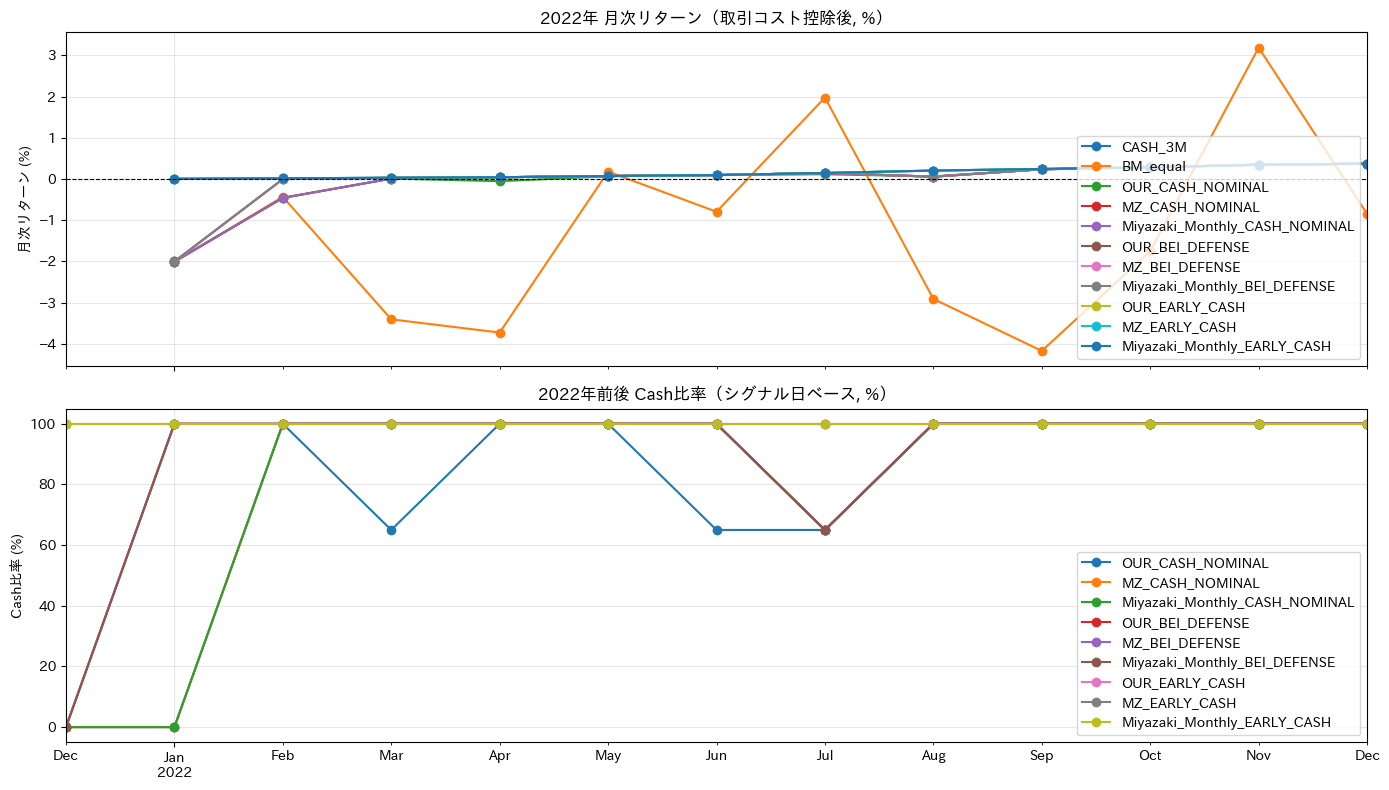

,OUR_CASH_NOMINAL,MZ_CASH_NOMINAL,Miyazaki_Monthly_CASH_NOMINAL,OUR_BEI_DEFENSE,MZ_BEI_DEFENSE,Miyazaki_Monthly_BEI_DEFENSE,OUR_EARLY_CASH,MZ_EARLY_CASH,Miyazaki_Monthly_EARLY_CASH
2021-12-31,0.00,0.00,0.00,0.00,0.00,0.00,1.0,1.0,1.0
2022-01-31,0.00,0.00,0.00,1.00,1.00,1.00,1.0,1.0,1.0
2022-02-28,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.0,1.0
2022-03-31,0.65,1.00,1.00,1.00,1.00,1.00,1.0,1.0,1.0
2022-04-30,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.0,1.0
2022-05-31,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.0,1.0
2022-06-30,0.65,1.00,1.00,1.00,1.00,1.00,1.0,1.0,1.0
2022-07-31,0.65,0.65,0.65,0.65,0.65,0.65,1.0,1.0,1.0
2022-08-31,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.0,1.0
2022-09-30,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.0,1.0


In [10]:
print("2022年リターン（取引コスト控除後, 単純合計）")
display((returns_net.loc["2022"].sum() * 100).round(2).to_frame("2022 Return %"))

cash_2022 = pd.DataFrame({
    name: weight_dfs[name].loc["2021-12-31":"2022-12-31", "Cash"]
    for name in strategy_config
})

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
returns_net.loc["2022"].mul(100).plot(ax=axes[0], marker="o")
axes[0].set_title("2022年 月次リターン（取引コスト控除後, %）")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("月次リターン (%)")
axes[0].grid(True, alpha=0.3)

cash_2022.mul(100).plot(ax=axes[1], marker="o")
axes[1].set_title("2022年前後 Cash比率（シグナル日ベース, %）")
axes[1].set_ylabel("Cash比率 (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(cash_2022.round(3))

## 累積リターンとドローダウン

防御ゲートを入れると、BMやフル債券戦略とはかなり違う絶対収益型の性格になる。累積リターンとドローダウンで確認する。

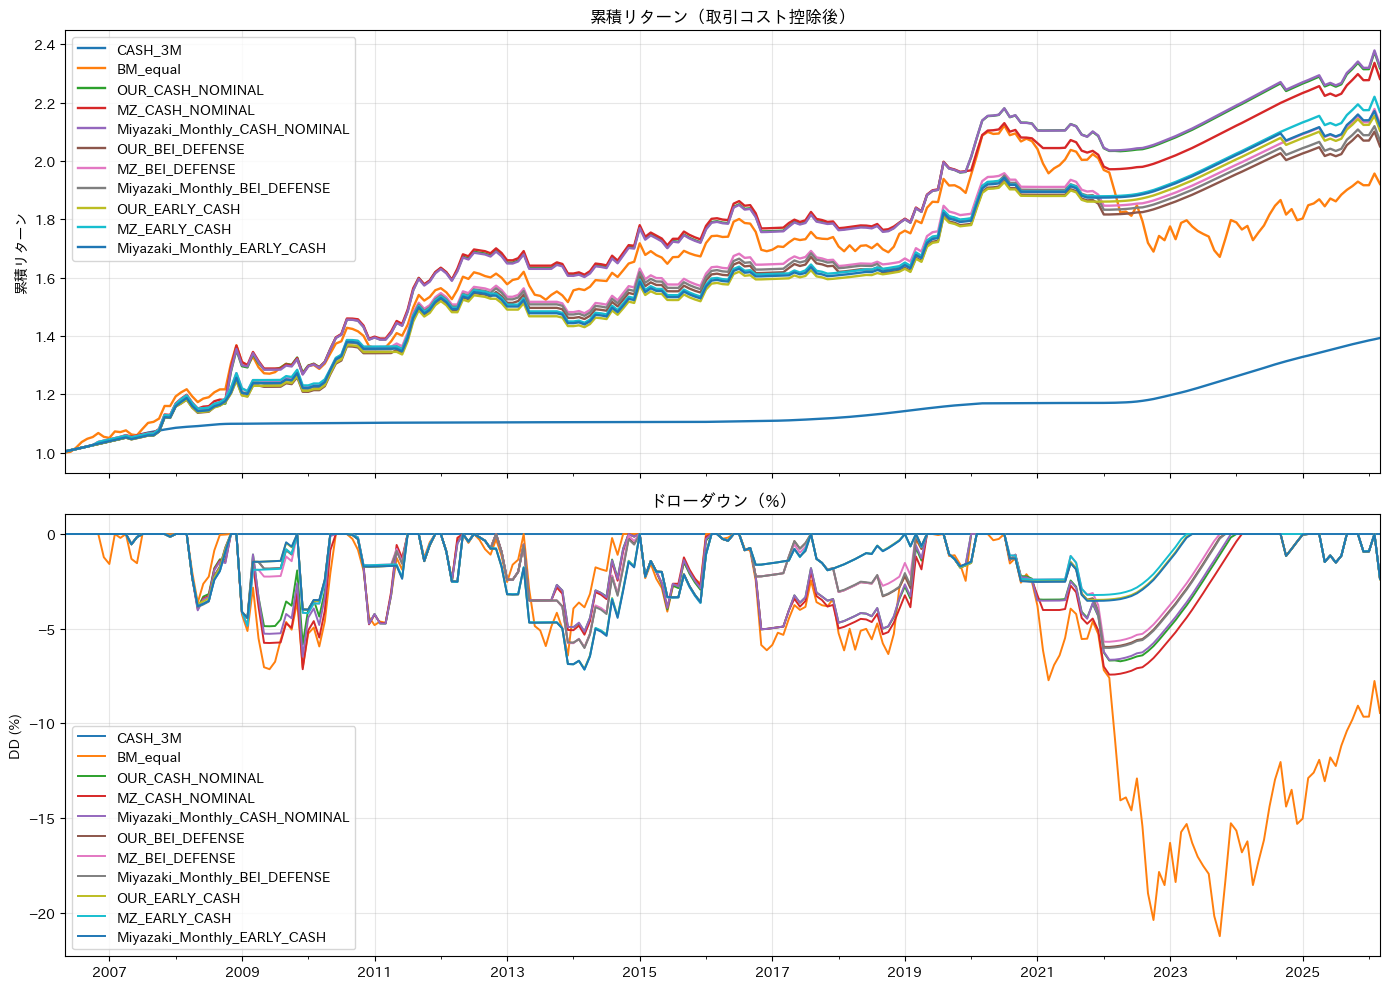

In [11]:
cum_net = (1 + returns_net).cumprod()
drawdowns = cum_net / cum_net.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

cum_net.plot(ax=axes[0], linewidth=1.7)
axes[0].set_title("累積リターン（取引コスト控除後）")
axes[0].set_ylabel("累積リターン")
axes[0].grid(True, alpha=0.3)

drawdowns.mul(100).plot(ax=axes[1], linewidth=1.4)
axes[1].set_title("ドローダウン（%）")
axes[1].set_ylabel("DD (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 早期警戒ゲートの点灯確認

2021年末から2022年初にかけて、2年金利モメンタムとBEI高止まりが先に点灯する。このため `EARLY_CASH` は2021年12月末のシグナルでキャッシュ100%へ退避する。

In [12]:
rows = []
for dt in pd.date_range("2021-09-30", "2022-03-31", freq="ME"):
    record = {"date": dt}
    for mode in ["nominal", "bei", "early"]:
        state = defense_state(dt, mode)
        record[f"{mode}_state"] = state["state"]
        record[f"{mode}_score"] = state["score"]
    flags = risk_flags(dt, "early")
    record.update({k: int(v) for k, v in flags.items()})
    rows.append(record)

early_check = pd.DataFrame(rows).set_index("date")
display(early_check)

,nominal_state,nominal_score,bei_state,bei_score,early_state,early_score,d10_3m_up,d10_6m_up,d3m_3m_up,curve_inverted,real_3m_up,bei_3m_up,d2_3m_up,d2_6m_up,bei_high
date,,,,,,,,,,,,,,,
2021-09-30,risk_on,0,risk_on,0,risk_on,0,0,0,0,0,0,0,0,0,0
2021-10-31,risk_on,1,risk_on,1,caution,3,1,0,0,0,0,0,1,0,1
2021-11-30,risk_on,0,risk_on,1,caution,3,0,0,0,0,0,1,1,0,1
2021-12-31,risk_on,0,risk_on,1,crisis,4,0,0,0,0,0,1,1,1,1
2022-01-31,risk_on,1,caution,2,crisis,4,0,1,0,0,1,0,1,1,0
2022-02-28,caution,3,crisis,4,crisis,7,1,1,1,0,1,0,1,1,1
2022-03-31,caution,3,crisis,5,crisis,8,1,1,1,0,1,1,1,1,1


## 結果保存

バックテスト結果、サマリー、ウエイト、ゲート状態をExcelへ保存する。

In [13]:
with pd.ExcelWriter(RESULT_PATH) as writer:
    returns_gross.to_excel(writer, sheet_name="returns_gross")
    returns_net.to_excel(writer, sheet_name="returns_net")
    summary_gross.to_excel(writer, sheet_name="summary_gross")
    summary_net.to_excel(writer, sheet_name="summary_net")
    turnover_df.to_excel(writer, sheet_name="turnover")
    defense_df.to_excel(writer, sheet_name="defense_states", index=False)
    for name, wdf in weight_dfs.items():
        wdf.to_excel(writer, sheet_name=f"weights_{name}"[:31])

print(f"保存完了: {RESULT_PATH}")

保存完了: ../data/backtest_defensive_cash_gated.xlsx


## 読み取り

`EARLY_CASH` 系は、2022年に短期金利へ完全退避できる。代償として、平均Cash比率が高くなり、リスクオン局面で債券フル投資より機会損失が出る。それでも、ネガティブキャリーとレベル損失を強く避けたい目的には最も合う。

今回追加した `Miyazaki_Monthly` は、半年Miyazakiシグナルを6で割る近似ではなく、シグナル計算そのものを1か月ホライズンへ直した版である。`MZ_EARLY_CASH` と `Miyazaki_Monthly_EARLY_CASH` の比較により、宮崎手法の月次化が最終戦略にどれだけ効くかを確認する。

第一候補は、実行結果のリターン、最大DD、短期金利対比IR、2022年Cash退避を総合して判断する。